## Titanic dataset

Ejercicio: Enfréntate al conjunto de datos Titanic. Un buen sitio para empezar es [Kaggle](https://www.kaggle.com/c/titanic).

Alternativamente, puedes descargar los datos de https://homl.info/titanic.tgz y descomprimir este tarball. Esto te dará dos archivos CSV. Obtendrás dos archivos CSV: _train.csv_ y _test.csv_ que puede cargar con `pandas.read_csv()`.

El objetivo es entrenar un clasificador que pueda predecir la columna «Sobrevivido» basándose en las otras columnas.

In [7]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_titanic_data():
    tarball_path = Path("datasets/titanic.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as titanic_tarball:
            titanic_tarball.extractall(path="datasets")
    return [pd.read_csv(Path("datasets/titanic") / filename)
            for filename in ("train.csv", "test.csv")]

In [8]:
train_data, test_data = load_titanic_data()

Los datos ya están divididos en un conjunto de entrenamiento y un conjunto de prueba. Sin embargo, los datos de prueba *no* contienen las etiquetas: tu objetivo es entrenar el mejor modelo que puedas con los datos de entrenamiento, luego hacer tus predicciones con los datos de prueba y subirlas a Kaggle para ver tu puntuación final.

Echemos un vistazo a las primeras filas del conjunto de entrenamiento:

In [9]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Los atributos tienen el siguiente significado
* **PassengerId**: un identificador único para cada pasajero.
* **Survived**: es el objetivo, 0 significa que el pasajero no sobrevivió, mientras que 1 significa que sobrevivió.
* **Pclass**: clase de pasajero.
* **Nombre**, **Sexo**, **Edad**: se explica por sí mismo.
* **SibSp**: cuántos hermanos y cónyuges del pasajero a bordo del Titanic.
* **Parch**: cuántos hijos y padres del pasajero a bordo del Titanic.
* Billete: número de identificación del billete.
* Tarifa: precio pagado (en libras).
* Camarote: número de camarote del pasajero.
* Embarque: lugar donde el pasajero embarcó en el Titanic.

El objetivo es predecir si un pasajero ha sobrevivido o no basándose en atributos como su edad, sexo, clase de pasajero, lugar donde embarcó, etc.

Establezcamos explícitamente la columna `PassengerId` como columna índice:

In [11]:
train_data = train_data.set_index("PassengerId")
test_data = test_data.set_index("PassengerId")

Obtengamos más información para ver cuántos datos faltan:

In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [13]:
train_data[train_data["Sex"]=="female"]["Age"].median()

27.0

Bien, los atributos **Edad**, **Cabina** y **Embarcado** son a veces nulos (menos de 891 no nulos), especialmente el **Cabina** (77% son nulos). Por ahora, ignoraremos **Cabina** y nos centraremos en el resto. El atributo **Edad** tiene alrededor de un 19% de valores nulos, por lo que tendremos que decidir qué hacer con ellos.

Sustituir los valores nulos por la mediana de edad parece razonable. Podríamos ser un poco más inteligentes y predecir la edad basándonos en las otras columnas (por ejemplo, la mediana de edad es 37 en 1ª clase, 29 en 2ª clase y 24 en 3ª clase), pero mantendremos las cosas sencillas y nos limitaremos a utilizar la mediana de edad global.

Los atributos **Nombre** y **Ticket** pueden tener algún valor, pero será un poco complicado convertirlos en números útiles que un modelo pueda consumir. Así que, por ahora, los ignoraremos.

In [14]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699113,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526507,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.416700,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* Sólo el 38% **Sobrevivió**! 😭 Está bastante cerca del 40%, así que la precisión será una métrica razonable para evaluar nuestro modelo.
* La tarifa media era de 32,20 libras, lo que no parece tan caro (pero probablemente era mucho dinero por aquel entonces).
* La edad media era inferior a 30 años.

Comprobemos que el objetivo es efectivamente 0 ó 1:

In [15]:
train_data["Survived"].value_counts()

,count
Survived,
0,549
1,342


Ahora echemos un vistazo rápido a todos los atributos categóricos:

In [16]:
train_data["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [17]:
train_data["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [18]:
train_data["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


Podemos hacer conversión de datos teniendo en cuenta los siguientes puntos importantes:



In [19]:
train_data["AgeBucket"] = train_data["Age"] // 15 * 15
train_data[["AgeBucket", "Survived"]].groupby(['AgeBucket']).mean()

,Survived
AgeBucket,
0.0,0.576923
15.0,0.362745
30.0,0.423256
45.0,0.404494
60.0,0.240000
75.0,1.000000


In [20]:
train_data["RelativesOnboard"] = train_data["SibSp"] + train_data["Parch"]
train_data[["RelativesOnboard", "Survived"]].groupby(
    ['RelativesOnboard']).mean()

,Survived
RelativesOnboard,
0,0.303538
1,0.552795
2,0.578431
3,0.724138
4,0.200000
5,0.136364
6,0.333333
7,0.000000
10,0.000000


1. los distintos grupos de edad tenían tasas de supervivencia muy diferentes, por lo que puede ser útil crear una categoría de edad y utilizarla en lugar de la edad.

2. Del mismo modo, puede ser útil tener una categoría especial para las personas que viajan solas, ya que sólo el 30% de ellas sobrevivieron.



In [21]:
# Función para preprocesar los datos
def preprocess_data(data):
    # Convertir la edad en categorías
    data['AgeBucket'] = pd.cut(data['Age'], bins=[0, 15, 30, 45, 60, 75, 90], labels=[0, 15, 30, 45, 60, 75])
    # Sumar SibSp y Parch
    data['RelativesOnboard'] = data['SibSp'] + data['Parch']
    # Extraer el título del nombre
    data['Title'] = data['Name'].apply(lambda x: x.split(', ')[1].split('.')[0])
    # Usar la primera letra de la cabina
    data['CabinType'] = data['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'U')
    return data

Podemos intentar otras creaciones, por ejemplo la letra de la cabina y si el titulo usando en el nombre nos ayuda.

In [22]:
train_data = preprocess_data(train_data)
test_data = preprocess_data(test_data)

In [23]:
train_data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeBucket,RelativesOnboard,Title,CabinType
PassengerId,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,15,1,Mr,U
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,30,1,Mrs,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,15,0,Miss,U
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,30,1,Mrs,C
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,30,0,Mr,U
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,15,0,Rev,U
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,15,0,Miss,B
889,0,3,"Johnston, Miss. Catherine Helen 'Carrie'",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,3,Miss,U


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


# Configuración de la tubería de preprocesamiento
numeric_features = ['Age', 'Fare', 'RelativesOnboard']
categorical_features = ['Pclass', 'Sex', 'CabinType', 'Embarked', 'Title', 'AgeBucket']

# Convert categorical features to string type before applying OneHotEncoder
for feature in categorical_features:
    train_data[feature] = train_data[feature].astype(str)
    test_data[feature] = test_data[feature].astype(str)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])



In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report

# Modelos a comparar
rf = Pipeline(steps=[('preprocessor', preprocessor),
                     ('classifier', RandomForestClassifier(random_state=42))])

svm = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', SVC(probability=True, random_state=42))])



In [26]:
# Configuración de Grid Search y Stochastic Grid Search
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_features': ['auto', 'sqrt', 'log2'],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

param_grid_rf_min = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30]
}


param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 'auto', 0.1, 1, 10],
    'classifier__kernel': ['linear','poly' , 'rbf'],
    'classifier__degree': [2, 3, 4]
}

# Grid Search
grid_search_rf = GridSearchCV(rf, param_grid_rf_min, cv=5, verbose=2, n_jobs=-1)
grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5, verbose=2, n_jobs=-1)

# Stochastic Grid Search
stochastic_search_rf = RandomizedSearchCV(rf, param_grid_rf_min, n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1)
stochastic_search_svm = RandomizedSearchCV(svm, param_grid_svm, n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1)


In [27]:

X_train = train_data.drop('Survived', axis=1)
y_train = train_data['Survived']
X_test = test_data


In [28]:
# Entrenamiento y Evaluación (Descomentar y ajustar cuando tengas los datos listos)
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_
y_pred_rf_GS = best_rf.predict(X_test)
print("Mejores parámetros RandomForest:", grid_search_rf.best_params_)


# print("Reporte de clasificación RandomForest:\n", classification_report(y_test, y_pred_rf))



Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros RandomForest: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}


In [29]:
# Entrenamiento y Evaluación (Descomentar y ajustar cuando tengas los datos listos)
grid_search_svm.fit(X_train, y_train)
best_svm = grid_search_svm.best_estimator_
y_pred_svm_GS= best_svm.predict(X_test)
print("Mejores parámetros RandomForest:", grid_search_svm.best_params_)



Fitting 5 folds for each of 135 candidates, totalling 675 fits


KeyboardInterrupt: 

Ahora miremos como ajustar los hiperparametros usando una busqueda estocástica.

In [30]:
stochastic_search_svm.fit(X_train, y_train)
best_svm_SS = stochastic_search_svm.best_estimator_
y_pred_svm_SS = best_svm_SS.predict(X_test)
print("Mejores parámetros SVM:", stochastic_search_svm.best_params_)

# print("Reporte de clasificación SVM:\n", classification_report(y_test, y_pred_svm))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros SVM: {'classifier__kernel': 'rbf', 'classifier__gamma': 'auto', 'classifier__degree': 3, 'classifier__C': 10}


In [31]:
stochastic_search_rf.fit(X_train, y_train)
best_rf_SS = stochastic_search_rf.best_estimator_
y_pred_rf_SS = best_rf_SS.predict(X_test)
print("Mejores parámetros SVM:", stochastic_search_rf.best_params_)

# print("Reporte de clasificación SVM:\n", classification_report(y_test, y_pred_svm))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros SVM: {'classifier__n_estimators': 100, 'classifier__max_depth': 10}


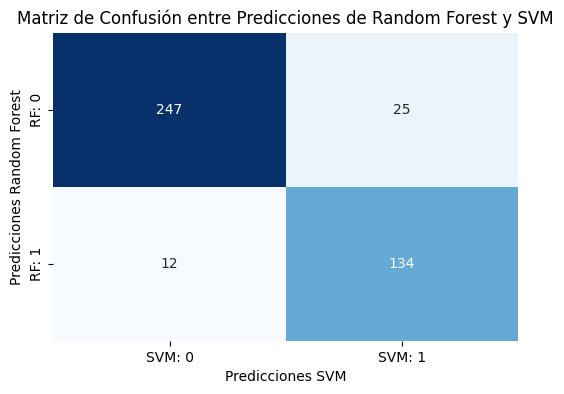

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Asumiendo que ya tienes y_pred_rf (predicciones de Random Forest) y y_pred_svm (predicciones de SVM)

# Crear la matriz de confusión entre las predicciones de Random Forest y SVM
conf_matrix = confusion_matrix(y_pred_rf_SS, y_pred_svm_SS)

# Dibujar la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['SVM: 0', 'SVM: 1'],
            yticklabels=['RF: 0', 'RF: 1'])

plt.title('Matriz de Confusión entre Predicciones de Random Forest y SVM')
plt.xlabel('Predicciones SVM')
plt.ylabel('Predicciones Random Forest')
plt.show()


Nuestro modelo está entrenado, usémoslo para hacer predicciones en el conjunto de pruebas:

Pero en lugar de fijarnos sólo en la precisión media de los 10 pliegues de validación cruzada, vamos a representar las 10 puntuaciones de cada modelo, junto con un diagrama de cajas que resalta los cuartiles inferior y superior, y «bigotes» que muestran la extensión de las puntuaciones.


 En concreto, si el cuartil inferior es $Q_1$ y el cuartil superior es $Q_3$, entonces el rango intercuartílico $IQR = Q_3 - Q_1$ (ésta es la altura de la caja), y cualquier puntuación inferior a $Q_1 - 1,5 \times IQR$ es un valor atípico, y también lo es cualquier puntuación superior a $Q3 + 1,5 \times IQR$.

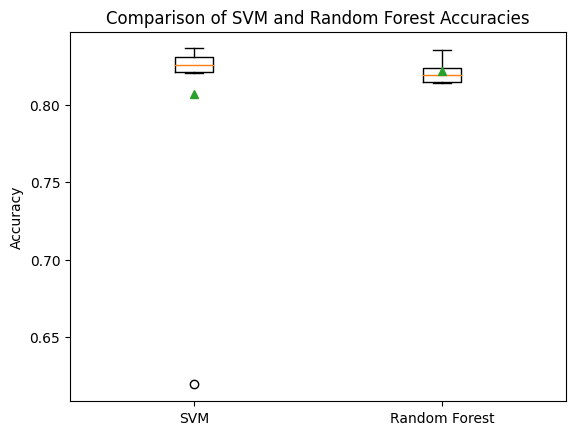

In [33]:
# Acceder a los resultados de cada iteración de RandomizedSearchCV
results_rf = stochastic_search_rf.cv_results_['mean_test_score']
results_svm = stochastic_search_svm.cv_results_['mean_test_score']

# Crear los boxplots para comparar los resultados de precisión (accuracy)
fig, ax = plt.subplots()

# Crear el boxplot con los datos de SVM y Random Forest
ax.boxplot([results_svm, results_rf], labels=['SVM', 'Random Forest'], showmeans=True)

# Etiquetas y título
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of SVM and Random Forest Accuracies')

# Mostrar gráfico
plt.show()


El clasificador de bosque aleatorio obtuvo una puntuación muy alta en uno de los 10 pliegues, pero en general tuvo una puntuación media más baja, así como una mayor dispersión, por lo que parece que el clasificador SVM tiene más probabilidades de generalizar bien.